In [226]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torchvision import datasets
from collections import Counter

In [227]:
import torch.nn as nn

In [228]:
import random

In [229]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [230]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

generator = torch.Generator()
generator.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [231]:
train_dataset = datasets.ImageFolder('Data/NEU-DET/train/images')

Total classes and images per class

In [232]:
counter = Counter()
class_counts = Counter(train_dataset.targets)

print(f"Total Images: {len(train_dataset)}")
print(f"Image classes: {train_dataset.classes}")

for class_idx, class_name in enumerate(train_dataset.classes):
    print(f"{class_name}: {class_counts[class_idx]}")

Total Images: 1440
Image classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
crazing: 240
inclusion: 240
patches: 240
pitted_surface: 240
rolled-in_scale: 240
scratches: 240


Image information: Considering information from `crazing`

In [233]:
image, label = train_dataset[0]
print(f"Image Class: {train_dataset.classes[label]}")
print(f"Image Dimension: {image.size}")

Image Class: crazing
Image Dimension: (200, 200)


<h3>Image Normalization</h3> <br>
Normalization scales pixel values to a common range (such as 0–1 or −1 to 1) before training a CNN. It is important because it:

- Speeds up model convergence.
- Produces more stable gradients during backpropagation.
- Improves the efficiency of optimization algorithms.
- Prevents features with large values from dominating learning.
- Often leads to better accuracy and more stable training.

In [234]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # ensuring all images in grayscale format i.e B&W
    transforms.Resize((200,200)), # although images are already in dimension 200x200, ensuring it for all
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

`ImageFolder` stores the images data, their classes and all other required information regarding image data

In [235]:
train_dataset = datasets.ImageFolder(
    root='Data/NEU-DET/train/images',
    transform=transform
)

`DataLoader` feeds chunks of image data from every classes in a batch for training a model.

In [236]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True,
    generator=generator,
    num_workers=0,
    worker_init_fn=seed_worker,
)

In [237]:
# Validation dataset from folder (separate from train split)
val_dataset = datasets.ImageFolder(
    root='Data/NEU-DET/validation/images',
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

<h3>Building a CNN classifier </h3>

In [238]:
class CNN_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(

            # first convolution layer

            nn.Conv2d(
                in_channels=1, # since we have Grayscale image so defining channel size 1
                out_channels=32, # taking 32 kernels of 3x3 size
                kernel_size=3,  # selecting a kernel of 3x3 size
                stride=1, # stride slides scanning 1 step (1 step right, 1 step down and so on)
                padding=1, # padding adds an extra layer/border to prevent missing of important borderline features
                # for now extra padding of values 0 are assigned
            ),

            nn.ReLU(), # Applying ReLU activation to final feature matrix

            nn.MaxPool2d(
                kernel_size=2 , # using maxpool pooling with kernel 2x2
            ),

            # second convolution layer

            nn.Conv2d(
                in_channels=32, # since our input from previous conv layer is 100x100(with 32 kernel values)
                out_channels=64, # defining 64 kernels for conv. layer 2
                stride=1,
                kernel_size=3, # defining 3x3 kernel for conv. layer 2
                padding=1,
            ),

            nn.ReLU(), # again applying relu activation for conv. layer 2 feature matrix

            nn.MaxPool2d(2), # using max pooling with kernel size (2,2)

        )

        self.classifier = nn.Sequential(
            
            nn.Flatten(), # making the pixel in 1 dim

            nn.Linear(              # defining the fully-connected linear layer
                in_features=(50*50*64),
                out_features=128,
                bias=True,
            ),

            nn.ReLU(), # using Relu activation to add non-linearity

            nn.Linear(      # Again full-connected linear layer
            in_features=128,
            out_features=6   # since we have 6 image classes
            ),

        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


<h4>Model Architecture</h4> 

`Convolution Layer 1`

- Input size (`200x200`)
- Padding (1)
- Input size after padding (`202x202`)
- Kernel size (`3x3`)
- Number of kernels (`32`)
- stride (`1`)
- Feature Matrix size (`200x200x32`) 
- `Feature Matrix size = ((n-m+2(p) / stride) x (n-m+2(p) / stride))`
- Final feature size after pooling (`100x100x32`)

`Convolution layer 2`

- Input size (`100x100`)
- Padding (`1`)
- Input size after padding (`102x102`)
- kernel size (`3x3`)
- Number of kernel (`64`)
- stride (`1`)
- Feature Matrix size (`100x100x64`)
- Final size after pooling (`50x50x64`)

`Linearity`

- Fully connected linear layer with `160000` input and `128` output
- Relu activation
- Fully connected linear layer with `128` input and `6` output

<h3>Training Pipeline</h3>

In [239]:
from torch.optim import Adam

In [240]:
model = CNN_classifier().to(device=device)
print(model.parameters)
EPOCHES = 15
criterion = nn.CrossEntropyLoss()   # using multi-class cross entropy loss
optimizer = Adam(params=model.parameters(), lr=0.001)  # taking learning rate 0.001

<bound method Module.parameters of CNN_classifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=160000, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)>


`Description of training pipeline`

- Taking the epoch value `15`.
- First, Training the model through a batch.
- Calculating the training loss and accuracy at each batch.
- After training through a batch, model is evaluated on shuffled batch with the same parameter it was trained.
- Then, Validation loss for each batch is calculated.
- Above steps are repeated upto `15` epoch.

In [ ]:
TRAIN_LOSS = []
TRAIN_ACC = []
VAL_LOSS = []
VAL_ACC = []

for epoch in range (EPOCHES):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:   # Loading a batch of size 32

        # moving the image to GPU
        images = images.to(device)  
        labels = labels.to(device)

        # Reset gradients of all model parameters
        optimizer.zero_grad()

        # forward propagation
        predictions = model(images)

        # computing loss
        loss = criterion(predictions, labels)

        # Note: the model is producing the class of the images i.e label (for our case 0-5)
        # We do not compare the predictions with images (tensor of images)

        loss.backward()

        optimizer.step()    

        running_loss += loss.item() * images.size(0)  
        # we computed the running loss, since CrossEntropy returns mean of the loss, so (loss * batch_size)

        preds = predictions.argmax(dim=1) # predicted labels

        correct += (preds == labels).sum().item() # checking predicted labels == actual labels

        total += labels.size(0) 

    train_loss_epoch = running_loss / total  # training loss per epoch
    train_acc_epoch = correct / total  # training accuracy per epoch

    TRAIN_LOSS.append(train_loss_epoch)
    TRAIN_ACC.append(train_acc_epoch)

    

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total

    VAL_LOSS.append(val_loss)
    VAL_ACC.append(val_acc)


    print(
    f"Epoch {epoch+1:2d} | "
    f"Train Loss: {train_loss_epoch:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Train Acc: {train_acc_epoch:.4f} |"
    f"Val Acc: {val_acc:.4f}"
    )

Epoch  1 | Train Loss: 1.3860 | Val Loss: 0.4823 | Train Acc: 0.5479 |Val Acc: 0.8409
Epoch  2 | Train Loss: 0.5340 | Val Loss: 0.4866 | Train Acc: 0.8187 |Val Acc: 0.8391
Epoch  3 | Train Loss: 0.3446 | Val Loss: 0.4872 | Train Acc: 0.8819 |Val Acc: 0.8386
Epoch  4 | Train Loss: 0.2567 | Val Loss: 0.4856 | Train Acc: 0.9146 |Val Acc: 0.8391
Epoch  5 | Train Loss: 0.1532 | Val Loss: 0.4866 | Train Acc: 0.9535 |Val Acc: 0.8386
Epoch  6 | Train Loss: 0.1660 | Val Loss: 0.4858 | Train Acc: 0.9444 |Val Acc: 0.8386
Epoch  7 | Train Loss: 0.1630 | Val Loss: 0.4850 | Train Acc: 0.9583 |Val Acc: 0.8390
Epoch  8 | Train Loss: 0.1097 | Val Loss: 0.4835 | Train Acc: 0.9688 |Val Acc: 0.8393
Epoch  9 | Train Loss: 0.1750 | Val Loss: 0.4846 | Train Acc: 0.9507 |Val Acc: 0.8387
Epoch 10 | Train Loss: 0.1419 | Val Loss: 0.4841 | Train Acc: 0.9556 |Val Acc: 0.8386
Epoch 11 | Train Loss: 0.1049 | Val Loss: 0.4822 | Train Acc: 0.9694 |Val Acc: 0.8391
Epoch 12 | Train Loss: 0.0551 | Val Loss: 0.4806 | Tra

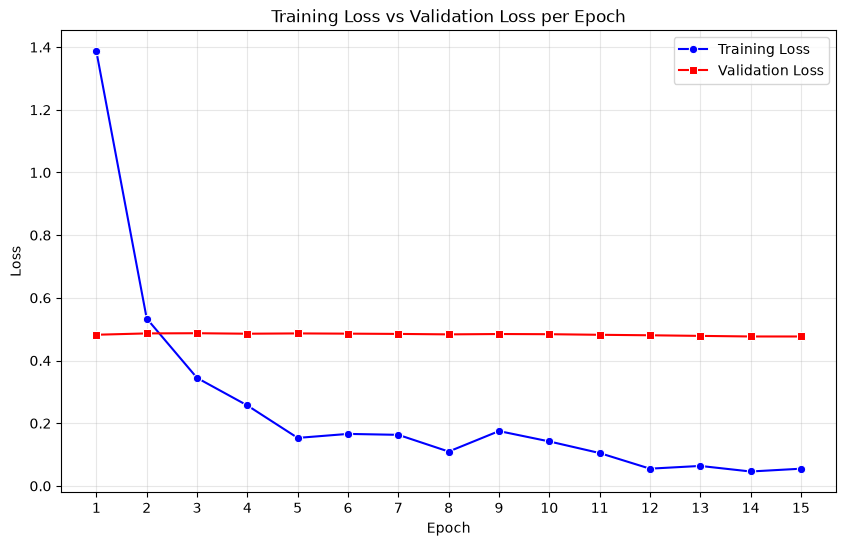

In [242]:
# Training loss vs Validation loss per epoch
epochs_axis = list(range(1, EPOCHES + 1))

plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs_axis, y=TRAIN_LOSS, marker="o", label="Training Loss", c="b")
sns.lineplot(x=epochs_axis, y=VAL_LOSS, marker="s", label="Validation Loss", c="r")

plt.title("Training Loss vs Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<b>`Model has overfit after 5 epoch`</b>

In [243]:
from sklearn.metrics import f1_score, classification_report

# Validation F1 score
model.eval()
all_val_preds = []
all_val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_val_preds.extend(preds.cpu().numpy())
        all_val_labels.extend(labels.cpu().numpy())

f1_macro = f1_score(all_val_labels, all_val_preds, average="macro")
f1_weighted = f1_score(all_val_labels, all_val_preds, average="weighted")
f1_micro = f1_score(all_val_labels, all_val_preds, average="micro")

print(f"Validation F1 Score (Macro):    {f1_macro:.4f}")
print(f"Validation F1 Score (Weighted): {f1_weighted:.4f}")
print(f"Validation F1 Score (Micro):    {f1_micro:.4f}")

print("\nClass-wise report:")
print(classification_report(all_val_labels, all_val_preds, target_names=val_dataset.classes, digits=4))

Validation F1 Score (Macro):    0.8486
Validation F1 Score (Weighted): 0.8486
Validation F1 Score (Micro):    0.8556

Class-wise report:
                 precision    recall  f1-score   support

        crazing     1.0000    0.9833    0.9916        60
      inclusion     0.6522    0.7500    0.6977        60
        patches     0.9677    1.0000    0.9836        60
 pitted_surface     0.8182    0.9000    0.8571        60
rolled-in_scale     0.8696    1.0000    0.9302        60
      scratches     0.8571    0.5000    0.6316        60

       accuracy                         0.8556       360
      macro avg     0.8608    0.8556    0.8486       360
   weighted avg     0.8608    0.8556    0.8486       360



<h3>Data Augmentation</h3>

<b>`Why should we perform data augmentation?`</b>

- Improves model generalization by exposing the model to different variations of the same defect, enabling better performance on unseen production data.
- Simulates real production conditions, such as slight camera misalignment, conveyor belt movement, and variations in defect position or orientation.
- Enhances robustness to environmental changes, including differences in lighting, camera exposure, and minor image distortions commonly encountered in industrial inspection systems.
- Reduces overfitting by preventing the model from memorizing the limited training images and encouraging it to learn meaningful defect characteristics.
- Minimizes the need for collecting large amounts of labeled data, making the defect detection system more practical and cost-effective for industrial applications.

<b>`Why we should not perform data augmentation in validation/test dataset?`</b>

- Ensures fair and unbiased evaluation by testing the model on original, unseen data rather than artificially modified images.
- Maintains a fixed and consistent benchmark, enabling reliable comparison of model performance across different epochs and experiments.
- Prevents data leakage, ensuring that only the training set is used to learn model parameters, while the validation and test sets remain independent for unbiased evaluation.
- Reflects real-world deployment conditions, since validation and test images should represent the actual data the model will encounter in production.

In [292]:
# defining a transformation parameters using torchvision.transforms
aug_train_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=1), # ensuring image is grayscale

    transforms.Resize(size= (200,200)),  # resize every image to size 200x200

    transforms.RandomHorizontalFlip(p=0.5), # randomly flip the image horizontally with 50% probability

    transforms.RandomRotation(15), # randomly rotate the image between -15 deg to +15 deg


# Randomly select a crop whose area is between 81% and 100% of the original image.
# Resize that crop to 180 × 180.

    transforms.RandomResizedCrop(  
        size = 200,
        scale = (0.81, 1.0)         
    ),

    transforms.ToTensor(),

    transforms.Normalize(mean=[0.5], std=[0.5])
]
)


In [293]:
aug_train_dataset = datasets.ImageFolder(
    root='Data/NEU-DET/train/images',
    transform=aug_train_transform
)

In [294]:
aug_train_dataset

Dataset ImageFolder
    Number of datapoints: 1440
    Root location: Data/NEU-DET/train/images
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               Resize(size=(200, 200), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
               RandomResizedCrop(size=(200, 200), scale=(0.81, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               ToTensor()
               Normalize(mean=[0.5], std=[0.5])
           )

In [295]:
aug_train_loader = DataLoader(
    dataset=aug_train_dataset,
    shuffle=True,
    num_workers=0,
    generator=generator,
    batch_size=32,
    worker_init_fn=seed_worker,
)

In [296]:
print(image.shape)

torch.Size([32, 1, 200, 200])


In [297]:
aug_model = CNN_classifier().to(device=device)
aug_optimizer = Adam(aug_model.parameters(), lr=0.001)

Training pipeline for `aug_model`

In [298]:
TRAIN_LOSS = []
VAL_LOSS = []
TRAIN_ACC = []
VAL_ACC = []

for epoch in range(EPOCHES):
    aug_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for aug_images, aug_labels in aug_train_loader:

        aug_images = aug_images.to(device)
        aug_labels = aug_labels.to(device)

        aug_optimizer.zero_grad()

        aug_prediction = aug_model(aug_images)

        aug_loss = criterion(aug_prediction, aug_labels)

        aug_loss.backward()

        aug_optimizer.step()


        running_loss += aug_loss.item() * aug_images.size(0)  
        

        aug_preds = aug_prediction.argmax(dim=1) # predicted labels

        correct += (aug_preds == aug_labels).sum().item() # checking predicted labels == actual labels

        total += aug_labels.size(0) 

    train_loss_epoch = running_loss / total  # training loss per epoch
    train_acc_epoch = correct / total  # training accuracy per epoch

    TRAIN_LOSS.append(train_loss_epoch)
    TRAIN_ACC.append(train_acc_epoch)

    

    aug_model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = aug_model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_acc = val_correct / val_total

    VAL_LOSS.append(val_loss)
    VAL_ACC.append(val_acc)


    print(
    f"Epoch {epoch+1:2d} | "
    f"Train Loss: {train_loss_epoch:.4f} | "
    f"Val Loss: {val_loss:.4f} | "
    f"Train Acc: {train_acc_epoch:.4f} |"
    f"Val Acc: {val_acc:.4f}"
    )

Epoch  1 | Train Loss: 1.5167 | Val Loss: 1.3087 | Train Acc: 0.4306 |Val Acc: 0.5806
Epoch  2 | Train Loss: 0.9537 | Val Loss: 1.4188 | Train Acc: 0.6813 |Val Acc: 0.5583
Epoch  3 | Train Loss: 0.6197 | Val Loss: 1.1580 | Train Acc: 0.8007 |Val Acc: 0.5861
Epoch  4 | Train Loss: 0.4861 | Val Loss: 1.3287 | Train Acc: 0.8542 |Val Acc: 0.5556
Epoch  5 | Train Loss: 0.4366 | Val Loss: 1.1492 | Train Acc: 0.8528 |Val Acc: 0.5806
Epoch  6 | Train Loss: 0.3636 | Val Loss: 0.9890 | Train Acc: 0.8736 |Val Acc: 0.6722
Epoch  7 | Train Loss: 0.3295 | Val Loss: 0.9617 | Train Acc: 0.8896 |Val Acc: 0.6250
Epoch  8 | Train Loss: 0.2838 | Val Loss: 0.8864 | Train Acc: 0.9111 |Val Acc: 0.7000
Epoch  9 | Train Loss: 0.2768 | Val Loss: 1.1273 | Train Acc: 0.9132 |Val Acc: 0.6694
Epoch 10 | Train Loss: 0.2908 | Val Loss: 1.6697 | Train Acc: 0.9014 |Val Acc: 0.6028
Epoch 11 | Train Loss: 0.2716 | Val Loss: 1.1423 | Train Acc: 0.9160 |Val Acc: 0.6389
Epoch 12 | Train Loss: 0.2001 | Val Loss: 0.7283 | Tra

<h3>Conclusion After Data Augmentation</h3>

- The validation accuracy increased from 55% to 77%
- Where as training accuracy increased from 43% to 92%
- It means model is learning on both validation set and training set

<br>

- Previously, The validation accuracy was steady or pleateau with accuracy of 84%
- On the other hand, Training accuracy was in range of 55% to 98%
- Hence, previously the model was overfitted

`Overfitting has been reduced slightly after data augmentation`